In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import linregress

In [2]:
nav = pd.read_csv("data/processed/clean_nav.csv")
performance = pd.read_csv("data/processed/clean_performance.csv")
benchmark = pd.read_csv("data/processed/clean_benchmark.csv")
fund_master = pd.read_csv("data/processed/clean_fund_master.csv")

In [4]:
nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

## Task 1 — Compute Daily Returns

In [5]:
nav = nav.sort_values(["amfi_code","date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [6]:
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


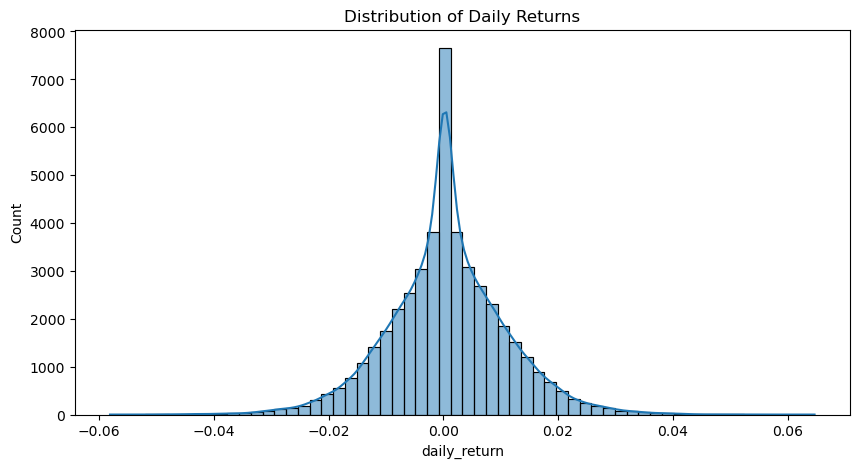

In [7]:
plt.figure(figsize=(10,5))

sns.histplot(nav["daily_return"].dropna(), bins=60, kde=True)

plt.title("Distribution of Daily Returns")
plt.show()

In [8]:
nav.to_csv("data/processed/nav_daily_returns.csv",index=False)

## Task 2 — CAGR (1Y, 3Y, 5Y)

In [9]:
def cagr(start,end,years):
    return ((end/start)**(1/years))-1

In [10]:
cagr_table=[]

for code in nav["amfi_code"].unique():

    df=nav[nav["amfi_code"]==code].sort_values("date")

    if len(df)<120:
        continue

    start=df.iloc[0]["nav"]
    end=df.iloc[-1]["nav"]

    years=(df["date"].max()-df["date"].min()).days/365

    value=cagr(start,end,years)

    cagr_table.append([code,value])

cagr_df=pd.DataFrame(
    cagr_table,
    columns=["amfi_code","CAGR"]
)

cagr_df.head()


,amfi_code,CAGR
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


## Task 3 — Sharpe Ratio

In [11]:
rf=0.065
sharpe=[]

for code in nav["amfi_code"].unique():

    r=nav[nav["amfi_code"]==code]["daily_return"].dropna()

    if len(r)==0:
        continue

    annual_return=r.mean()*252

    annual_std=r.std()*np.sqrt(252)

    s=(annual_return-rf)/annual_std

    sharpe.append([code,s])

sharpe_df=pd.DataFrame(
    sharpe,
    columns=["amfi_code","Sharpe"]
)

sharpe_df.sort_values(
    "Sharpe",
    ascending=False
).head()

,amfi_code,Sharpe
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


## Task 4 — Sortino Ratio

In [12]:
sortino=[]

for code in nav["amfi_code"].unique():

    r=nav[nav["amfi_code"]==code]["daily_return"].dropna()

    downside=r[r<0]

    downside_std=downside.std()*np.sqrt(252)

    annual_return=r.mean()*252

    ratio=(annual_return-rf)/downside_std

    sortino.append([code,ratio])

sortino_df=pd.DataFrame(
    sortino,
    columns=["amfi_code","Sortino"]
)

## Task 5 — Alpha & Beta

In [17]:
print(nav.shape)
print(benchmark.shape)
print(benchmark["index_name"].unique())

(46000, 4)
(8050, 3)
['NIFTY50' 'NIFTY100' 'NIFTY_MIDCAP150' 'BSE_SMALLCAP' 'NIFTY500'
 'CRISIL_LIQUID' 'CRISIL_GILT']


In [24]:
import pandas as pd
import numpy as np
from scipy.stats import linregress

# -------------------------------
# Prepare Benchmark Data
# -------------------------------

nifty = benchmark[benchmark["index_name"] == "NIFTY100"].copy()

nifty["benchmark_return"] = nifty["close_value"].pct_change()

nifty = nifty[["date", "benchmark_return"]].dropna()

# -------------------------------
# Calculate Alpha & Beta
# -------------------------------

alpha_beta_list = []

for code in nav["amfi_code"].unique():

    # Fund data
    fund = nav[nav["amfi_code"] == code][["date", "daily_return"]].copy()

    fund = fund.dropna()

    # Merge on date
    merged = pd.merge(
        fund,
        nifty,
        on="date",
        how="inner"
    )

    # Skip if insufficient observations
    if len(merged) < 30:
        print(f"Skipping {code} (Only {len(merged)} observations)")
        continue

    # Linear Regression
    slope, intercept, r_value, p_value, std_err = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha = intercept * 252      # Annualized Alpha
    beta = slope

    alpha_beta_list.append({
        "amfi_code": code,
        "Alpha": round(alpha, 6),
        "Beta": round(beta, 6),
        "R_squared": round(r_value**2, 4)
    })

# -------------------------------
# Create DataFrame
# -------------------------------

alpha_beta = pd.DataFrame(alpha_beta_list)

print(alpha_beta.head())

print("\nNumber of Funds Processed:", len(alpha_beta))

# -------------------------------
# Save CSV
# -------------------------------

alpha_beta.to_csv("alpha_beta.csv", index=False)

print("\nalpha_beta.csv saved successfully!")

   amfi_code     Alpha      Beta  R_squared
0     100016  0.037476 -0.058268     0.0027
1     100025  0.042818  0.001158     0.0000
2     100033  0.271954  0.005104     0.0000
3     101206  0.213998  0.021086     0.0003
4     101207  0.108971 -0.065289     0.0011

Number of Funds Processed: 40

alpha_beta.csv saved successfully!


In [19]:
print(alpha_beta.shape)

(0, 0)


In [21]:
print(nav["date"].min(), nav["date"].max())

print(benchmark["date"].min(), benchmark["date"].max())

print(nav["date"].dtype)

print(benchmark["date"].dtype)

2022-01-03 00:00:00 2026-05-29 00:00:00
2022-01-03 00:00:00 2026-05-29 00:00:00
datetime64[ns]
datetime64[ns]


In [22]:
nifty = benchmark[benchmark["index_name"] == "NIFTY100"]

print(nifty.head())

print(nifty.shape)

           date index_name  close_value
1150 2022-01-03   NIFTY100     17778.24
1151 2022-01-04   NIFTY100     17537.52
1152 2022-01-05   NIFTY100     17607.73
1153 2022-01-06   NIFTY100     17556.05
1154 2022-01-07   NIFTY100     17664.02
(1150, 3)


In [23]:
fund = nav[nav["amfi_code"] == nav["amfi_code"].iloc[0]]

print(fund.head())

print(fund.shape)

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
(1150, 4)


## Task 6 — Maximum Drawdown

In [27]:
drawdowns=[]

for code in nav["amfi_code"].unique():

    df=nav[
        nav["amfi_code"]==code
    ].copy()

    df["running_max"]=df["nav"].cummax()

    df["drawdown"]=(
        df["nav"]/df["running_max"]
    )-1

    drawdowns.append([
        code,
        df["drawdown"].min()
    ])

drawdown_df=pd.DataFrame(
    drawdowns,
    columns=[
        "amfi_code",
        "Max_Drawdown"
    ]
    
)

In [29]:
drawdown_df.head()

,amfi_code,Max_Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


## Task 7 — Fund Scorecard

## Merge:


In [30]:
score=cagr_df.merge(sharpe_df)

score=score.merge(alpha_beta)

score=score.merge(drawdown_df)

## Merge expense ratio:

In [31]:
score=score.merge(
    performance[
        ["amfi_code","expense_ratio_pct"]
    ]
)

In [33]:
score.head()

,amfi_code,CAGR,Sharpe,Alpha,Beta,R_squared,Max_Drawdown,expense_ratio_pct
0,100016,0.026352,-0.201517,0.037476,-0.058268,0.0027,-0.247344,1.55
1,100025,0.044551,-0.567095,0.042818,0.001158,0.0000,-0.043083,0.56
2,100033,0.300997,1.093699,0.271954,0.005104,0.0000,-0.162172,1.38
3,101206,0.235205,1.027213,0.213998,0.021086,0.0003,-0.112916,1.60
4,101207,0.079331,0.162661,0.108971,-0.065289,0.0011,-0.354469,1.53


## Ranking:

In [34]:
score["ReturnRank"]=score["CAGR"].rank()

score["SharpeRank"]=score["Sharpe"].rank()

score["AlphaRank"]=score["Alpha"].rank()

score["ExpenseRank"]=(
    -score["expense_ratio_pct"]
).rank()

score["DrawdownRank"]=(
    -score["Max_Drawdown"]
).rank()

## Composite Score:

In [35]:
score["FundScore"]=(
0.30*score["ReturnRank"]+
0.25*score["SharpeRank"]+
0.20*score["AlphaRank"]+
0.15*score["ExpenseRank"]+
0.10*score["DrawdownRank"]
)

score.sort_values(
    "FundScore",
    ascending=False
).head()

,amfi_code,CAGR,Sharpe,Alpha,Beta,R_squared,Max_Drawdown,expense_ratio_pct,ReturnRank,SharpeRank,AlphaRank,ExpenseRank,DrawdownRank,FundScore
25,120505,0.328016,1.180101,0.292636,0.000549,0.0000,-0.181885,1.36,40.0,36.0,38.0,26.0,25.0,35.000
21,119598,0.323981,0.945308,0.303370,-0.023196,0.0001,-0.287060,1.43,39.0,27.0,40.0,20.0,36.0,33.050
39,149324,0.322621,0.949796,0.300579,0.011455,0.0000,-0.311719,1.52,38.0,28.0,39.0,14.5,37.0,32.075
30,120843,0.308833,1.306744,0.273305,-0.022830,0.0003,-0.129740,1.45,35.0,39.0,36.0,19.0,13.0,31.600
2,100033,0.300997,1.093699,0.271954,0.005104,0.0000,-0.162172,1.38,34.0,34.0,35.0,24.0,20.0,31.300


In [36]:
score.to_csv(
    "fund_scorecard.csv",
    index=False
)

## Task 8 — Benchmark Comparison

In [37]:
top5=score.nlargest(
    5,
    "FundScore"
)["amfi_code"]

In [38]:
top5

25    120505
21    119598
39    149324
30    120843
2     100033
Name: amfi_code, dtype: int64

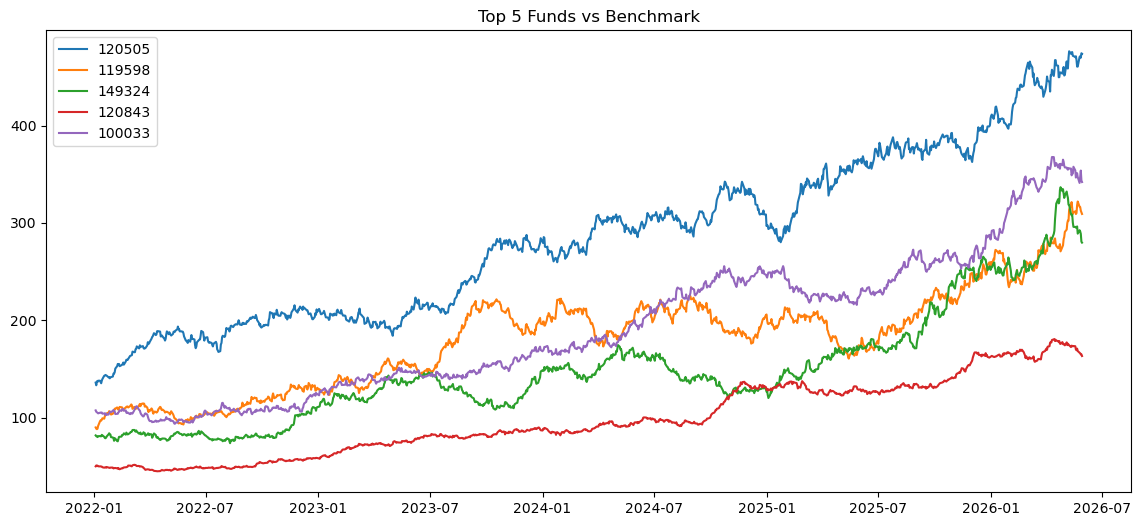

In [39]:
plt.figure(figsize=(14,6))

for code in top5:

    df=nav[
        nav["amfi_code"]==code
    ]

    plt.plot(
        df["date"],
        df["nav"],
        label=str(code)
    )

plt.legend()

plt.title("Top 5 Funds vs Benchmark")

plt.savefig(
    "reports/benchmark_comparison.png"
)

plt.show()